# Brain Tumor Segmentation on BRISC 2025 with YOLO26n-seg

**Author:** *[Assem Afanah]*
**Task:** Learning project for the deep learning module of the AI Engineering certificate. Apply instance segmentation of brain tumors (glioma, meningioma, pituitary) on T1-weighted MRI

## Overview

This notebook builds an instance-segmentation pipeline for brain MRI on the **BRISC 2025**
dataset — an expert-annotated collection of 6,000 T1-weighted brain MRI scans with
radiologist-verified tumor masks (Fateh et al., 2026,BRISC: Annotated Dataset for Brain Tumor Segmentation and Classification, *nature*,*Scientific Data*.). The segmentation
subset used here contains 4,793 image-mask pairs across three tumor classes (glioma,
meningioma, pituitary), annotated across axial, coronal, and sagittal planes.

**Pipeline:**
1. Convert binary PNG masks to YOLO polygon format
2. Apply denoising and split the data into train / val / test
3. Train a YOLO26n-seg model
4. Evaluate with COCO-style box/mask mAP and per-class breakdown
5. Inspect qualitative predictions on held-out test images

---

## 1. Environment setup

In [1]:
# Pin torch to the last release series with sm_60 (Pascal / P100) kernels, BEFORE
# installing anything else that depends on torch -- otherwise ultralytics/opencv can
# pull in whatever torch build pip resolves as "latest satisfying", which on current
# Kaggle images no longer includes Pascal support.
!pip install torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu118 -q
!pip install ultralytics opencv-python-headless -q
!pip install onnx onnxruntime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 72.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 30.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 44.2 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 10.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 32.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 14.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 9.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 12.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 131.3 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━

In [2]:
import os
import random
import shutil
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Ultralytics: {__import__('ultralytics').__version__}")
print(f"PyTorch: {torch.__version__}, CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Detected once and threaded explicitly through every YOLO call (train/val/predict) below.
# Passing an int here selects a CUDA device index; "cpu" forces CPU. Do not rely on
# Ultralytics' default, since model.val()/model.predict() do not always inherit the
# device the model was trained on and can silently fall back to CPU.
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# Kaggle mounts the dataset at /kaggle/input/<slug>/<top-folder>; 
# dataset path
DATASET_ROOT = Path("/kaggle/input/datasets/briscdataset/brisc2025/brisc2025")
WORK_DIR = Path("/kaggle/working")
YOLO_DATASET = WORK_DIR / "brisc_yolo_seg"

# BRISC filenames encode the tumor type as a 2-letter code, e.g.
#   brisc2025_train_00001_gl_ax_t1.jpg
#   gl = glioma, me = meningioma, pi = pituitary, nt = no_tumor
# Only the three tumor classes are used for segmentation (no_tumor has no mask).
CODE_TO_CLASS = {"gl": 0, "me": 1, "pi": 2}
CLASS_NAMES = ["glioma", "meningioma", "pituitary"]
NUM_CLASSES = len(CLASS_NAMES)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.104
PyTorch: 2.7.1+cu118, CUDA available: True
GPU: Tesla P100-PCIE-16GB
Using device: 0


In [3]:
# Verify the installed PyTorch build actually has kernels for this GPU's architecture,
# before doing anything expensive. Catches the classic "no kernel image is available for
# execution on the device" failure at setup time instead of mid-training.
if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability(0)
    gpu_arch = f"sm_{major}{minor}"
    supported_archs = torch.cuda.get_arch_list()
    print(f"GPU compute capability: {gpu_arch}")
    print(f"Archs supported by this torch build: {supported_archs}")

    # torch.cuda.get_arch_list() entries look like 'sm_70', 'sm_75', ..., or 'compute_90'.
    # An exact or lower matching sm_* entry means kernels exist for (or are forward-
    # compatible with) this GPU.
    def _arch_num(a):
        return int(a.split("_")[-1]) if a.split("_")[-1].isdigit() else -1

    supported_nums = sorted(_arch_num(a) for a in supported_archs if a.startswith("sm_"))
    this_num = major * 10 + minor
    compatible = any(s <= this_num for s in supported_nums) if supported_nums else False

    if not compatible:
        raise RuntimeError(
            f"This PyTorch build ({torch.__version__}) has no CUDA kernels compatible with "
            f"this GPU ({gpu_arch}). This is almost always caused by a `pip install -U` "
            f"pulling in a newer torch wheel that dropped support for this GPU's architecture "
            f"(common with older GPUs like Pascal/P100 on managed platforms such as Kaggle). "
            f"Fix: restart the kernel and reinstall a torch build that lists {gpu_arch} (or an "
            f"older/equal sm_* version) in torch.cuda.get_arch_list() -- e.g. an older cu11x "
            f"wheel from https://pytorch.org/get-started/previous-versions/ -- and avoid `-U` "
            f"on any install that pulls torch in as a dependency."
        )
    print("GPU/torch build compatibility check passed.")
else:
    print("No GPU detected -- running on CPU.")

GPU compute capability: sm_60
Archs supported by this torch build: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_37', 'sm_90']
GPU/torch build compatibility check passed.


## 2. Dataset structure

The `segmentation_task` folder uses a flat layout — all classes are mixed together under a
single `images/` and `masks/` directory per split, with class identity encoded only in the
filename:

```
segmentation_task/
├── train/
│   ├── images/*.jpg
│   └── masks/*.png
└── test/
    ├── images/*.jpg
    └── masks/*.png
```

There are no class subfolders, and mask/image pairs share the same basename.

In [4]:
seg_root = DATASET_ROOT / "segmentation_task"

print("Top level:")
for item in sorted(DATASET_ROOT.iterdir()):
    print(f"  {item.name}")

print("\nSegmentation task:")
for split_dir in sorted(seg_root.iterdir()):
    if not split_dir.is_dir():
        continue
    print(f"  {split_dir.name}/")
    for sub in sorted(split_dir.iterdir()):
        if sub.is_dir():
            print(f"    {sub.name}/  ({len(list(sub.iterdir()))} files)")

train_imgs = sorted((seg_root / "train" / "images").glob("*"))
train_masks = sorted((seg_root / "train" / "masks").glob("*"))
print(f"\nExample image filenames:")
for f in train_imgs[:5]:
    print(f"  {f.name}")
print(f"\nExample mask filenames:")
for f in train_masks[:5]:
    print(f"  {f.name}")

Top level:
  README.md
  classification_task
  manifest.csv
  manifest.csv.sha256
  manifest.json
  manifest.json.sha256
  segmentation_task

Segmentation task:
  test/
    images/  (860 files)
    masks/  (860 files)
  train/
    images/  (3933 files)
    masks/  (3933 files)

Example image filenames:
  brisc2025_train_00001_gl_ax_t1.jpg
  brisc2025_train_00002_gl_ax_t1.jpg
  brisc2025_train_00003_gl_ax_t1.jpg
  brisc2025_train_00004_gl_ax_t1.jpg
  brisc2025_train_00005_gl_ax_t1.jpg

Example mask filenames:
  brisc2025_train_00001_gl_ax_t1.png
  brisc2025_train_00002_gl_ax_t1.png
  brisc2025_train_00003_gl_ax_t1.png
  brisc2025_train_00004_gl_ax_t1.png
  brisc2025_train_00005_gl_ax_t1.png


## 3. Mask-to-polygon conversion

YOLO segmentation models require normalized polygon coordinates, but BRISC ships binary
PNG masks. The conversion pipeline is:

1. Read the mask and threshold it to binary
2. Extract contours with OpenCV
3. Simplify each contour with `approxPolyDP` (`epsilon = 0.002 * perimeter`)
4. Normalize coordinates to the `[0, 1]` range
5. Write in YOLO-seg format: `class_id x1 y1 x2 y2 ... xN yN`

An epsilon of 0.002 keeps enough boundary detail to be clinically meaningful while avoiding
polygons with excessive vertices, which slow down training. Contours smaller than
`min_area_frac` of the image area are dropped as annotation noise. `no_tumor` samples are
excluded from this task entirely, since their masks are blank and contribute no training
signal for instance segmentation.

The segmentation subset totals 3,933 training and 860 held-out test image-mask pairs.

In [5]:
def get_class_id_from_filename(filename):
    """Parse the tumor class from a BRISC filename.

    Pattern: brisc2025_<split>_<index>_<tumor_code>_<plane>_<seq>.<ext>
    tumor_code is the 4th underscore-separated field.
    """
    parts = Path(filename).stem.split("_")
    if len(parts) >= 4:
        return CODE_TO_CLASS.get(parts[3], None)
    return None


def mask_to_yolo_polygons(mask_path, class_id, epsilon_factor=0.002, min_area_frac=0.0005):
    """Convert a binary mask PNG into YOLO-seg polygon label lines."""
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []

    h, w = mask.shape
    img_area = h * w
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lines = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area_frac * img_area:
            continue
        perimeter = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon_factor * perimeter, True)
        if len(approx) < 3:
            continue
        coords = [f"{p[0][0] / w:.6f} {p[0][1] / h:.6f}" for p in approx]
        lines.append(f"{class_id} " + " ".join(coords))
    return lines


# Sanity check on the filename parser
for name in [
    "brisc2025_train_00001_gl_ax_t1.jpg",
    "brisc2025_train_00100_me_co_t1.jpg",
    "brisc2025_train_00200_pi_sa_t1.jpg",
    "brisc2025_train_00300_nt_ax_t1.jpg",
]:
    print(f"  {name} -> class_id={get_class_id_from_filename(name)}")

  brisc2025_train_00001_gl_ax_t1.jpg -> class_id=0
  brisc2025_train_00100_me_co_t1.jpg -> class_id=1
  brisc2025_train_00200_pi_sa_t1.jpg -> class_id=2
  brisc2025_train_00300_nt_ax_t1.jpg -> class_id=None


### Build the YOLO-format dataset

Converts every image/mask pair, writes YOLO-seg label files, and carves out a validation
split (15%) from the training images. The original test split is kept fully held out.

In [6]:
if YOLO_DATASET.exists():
    shutil.rmtree(YOLO_DATASET)

train_img_names = sorted(os.listdir(seg_root / "train" / "images"))
random.shuffle(train_img_names)
val_count = int(len(train_img_names) * 0.15)
val_set = set(train_img_names[:val_count])

for split in ["train", "val", "test"]:
    (YOLO_DATASET / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET / "labels" / split).mkdir(parents=True, exist_ok=True)

stats = {
    "train": Counter(), "val": Counter(), "test": Counter(),
    "skipped_no_class": 0, "skipped_empty": 0,
}

for src_split in ["train", "test"]:
    src_img_dir = seg_root / src_split / "images"
    src_mask_dir = seg_root / src_split / "masks"

    for img_name in sorted(os.listdir(src_img_dir)):
        stem = Path(img_name).stem

        class_id = get_class_id_from_filename(img_name)
        if class_id is None:
            stats["skipped_no_class"] += 1
            continue

        mask_path = src_mask_dir / f"{stem}.png"
        if not mask_path.exists():
            continue

        lines = mask_to_yolo_polygons(mask_path, class_id)
        if not lines:
            stats["skipped_empty"] += 1
            continue

        if src_split == "test":
            dst_split = "test"
        elif img_name in val_set:
            dst_split = "val"
        else:
            dst_split = "train"

        shutil.copy2(src_img_dir / img_name, YOLO_DATASET / "images" / dst_split / f"{stem}.jpg")
        with open(YOLO_DATASET / "labels" / dst_split / f"{stem}.txt", "w") as f:
            f.write("\n".join(lines) + "\n")

        stats[dst_split][CLASS_NAMES[class_id]] += 1

for split in ["train", "val", "test"]:
    n = len(os.listdir(YOLO_DATASET / "images" / split))
    print(f"{split}: {n} images, classes: {dict(stats[split])}")
print(f"Skipped (no class): {stats['skipped_no_class']}, skipped (empty mask): {stats['skipped_empty']}")

data_yaml_content = f"""path: {YOLO_DATASET}
train: images/train
val: images/val
test: images/test

nc: {NUM_CLASSES}
names: {CLASS_NAMES}"""

data_yaml_path = YOLO_DATASET / "data.yaml"
with open(data_yaml_path, "w") as f:
    f.write(data_yaml_content)

print(f"\ndata.yaml:\n{data_yaml_content}")

train: 3342 images, classes: {'glioma': 992, 'meningioma': 1128, 'pituitary': 1222}
val: 589 images, classes: {'glioma': 154, 'meningioma': 200, 'pituitary': 235}
test: 860 images, classes: {'glioma': 254, 'meningioma': 306, 'pituitary': 300}
Skipped (no class): 0, skipped (empty mask): 2

data.yaml:
path: /kaggle/working/brisc_yolo_seg
train: images/train
val: images/val
test: images/test

nc: 3
names: ['glioma', 'meningioma', 'pituitary']


## 4. Image preprocessing

Non-local means denoising is applied to every image in the converted dataset to reduce
MRI acquisition noise while preserving tumor boundary detail, which is more sensitive
to over-smoothing than to residual noise.

In [7]:
DENOISE_PARAMS = dict(h=10, hColor=10, templateWindowSize=7, searchWindowSize=21)

processed_count = 0
for split in ["train", "val", "test"]:
    image_dir = YOLO_DATASET / "images" / split
    if not image_dir.exists():
        continue
    for img_path in image_dir.glob("*.jpg"):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        denoised = cv2.fastNlMeansDenoisingColored(img, None, **DENOISE_PARAMS)
        cv2.imwrite(str(img_path), denoised)  # overwrite in place
        processed_count += 1

print(f"Denoising complete. Processed {processed_count} images.")

Denoising complete. Processed 4791 images.


## 5. Conversion verification

Visual sanity check: original MRI, ground-truth binary mask, and the polygon overlay
recovered from the YOLO label file, side by side.

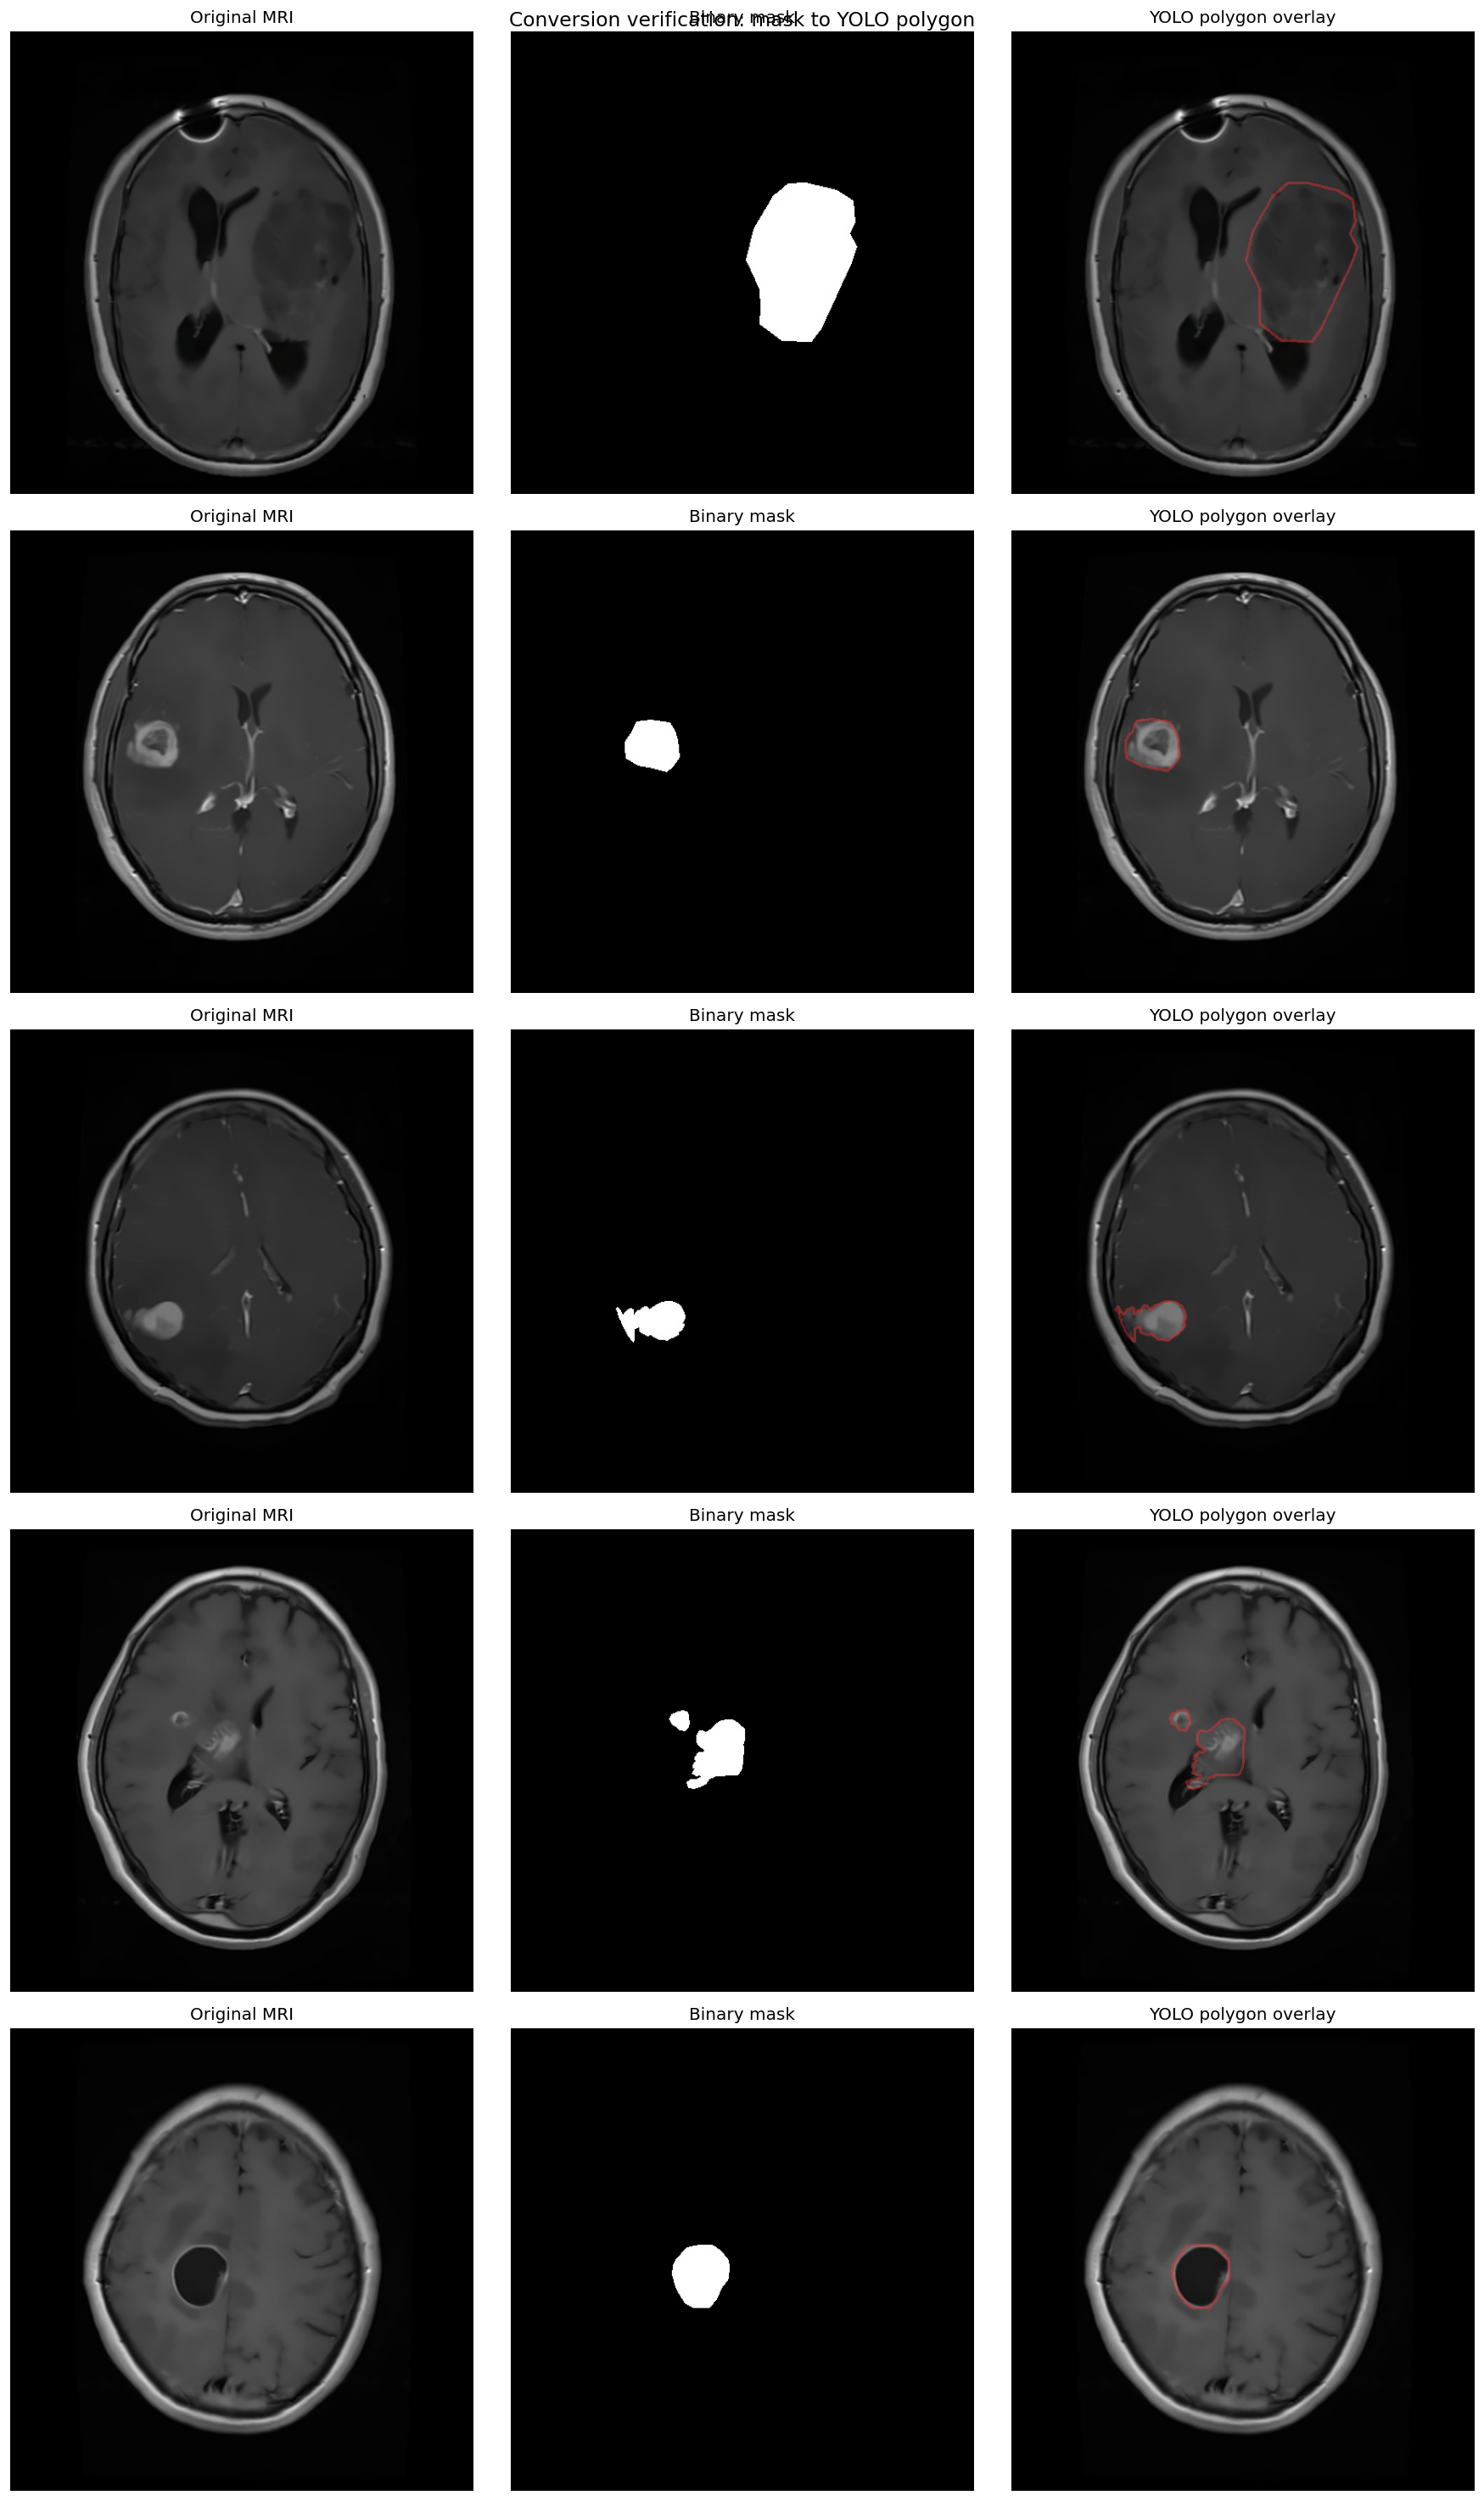

In [7]:
COLORS = {0: (255, 50, 50), 1: (50, 255, 50), 2: (50, 50, 255)}  # BGR-agnostic display colors per class

sample_labels = sorted((YOLO_DATASET / "labels" / "train").glob("*.txt"))[:5]
if len(sample_labels) < 5:
    sample_labels += sorted((YOLO_DATASET / "labels" / "val").glob("*.txt"))[: 5 - len(sample_labels)]

fig, axes = plt.subplots(len(sample_labels), 3, figsize=(15, 5 * len(sample_labels)))
if len(sample_labels) == 1:
    axes = axes[np.newaxis, :]

for idx, lbl_path in enumerate(sample_labels):
    stem = lbl_path.stem

    img_path = next(
        (YOLO_DATASET / "images" / s / f"{stem}.jpg" for s in ["train", "val"]
         if (YOLO_DATASET / "images" / s / f"{stem}.jpg").exists()),
        None,
    )
    if img_path is None:
        continue

    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    mask_display = np.zeros((h, w), dtype=np.uint8)
    for split_name in ["train", "test"]:
        m_path = seg_root / split_name / "masks" / f"{stem}.png"
        if m_path.exists():
            mask_display = cv2.imread(str(m_path), cv2.IMREAD_GRAYSCALE)
            break

    overlay = img_rgb.copy()
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            cls_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            points = [[int(coords[i] * w), int(coords[i + 1] * h)] for i in range(0, len(coords), 2)]
            cv2.polylines(overlay, [np.array(points, dtype=np.int32)], True, COLORS.get(cls_id, (255, 255, 0)), 2)

    blended = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)

    axes[idx, 0].imshow(img_rgb); axes[idx, 0].set_title("Original MRI"); axes[idx, 0].axis("off")
    axes[idx, 1].imshow(mask_display, cmap="gray"); axes[idx, 1].set_title("Binary mask"); axes[idx, 1].axis("off")
    axes[idx, 2].imshow(blended); axes[idx, 2].set_title("YOLO polygon overlay"); axes[idx, 2].axis("off")

plt.suptitle("Conversion verification: mask to YOLO polygon", fontsize=14)
plt.tight_layout()
plt.savefig(WORK_DIR / "conversion_verification.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Class distribution

Instance counts and polygon complexity (number of contour points) per class, computed
across the full converted dataset (train + val + test).

Instance counts per class:
  glioma: 1544 instances, avg 50.4 polygon points
  meningioma: 1685 instances, avg 61.3 polygon points
  pituitary: 1826 instances, avg 60.7 polygon points


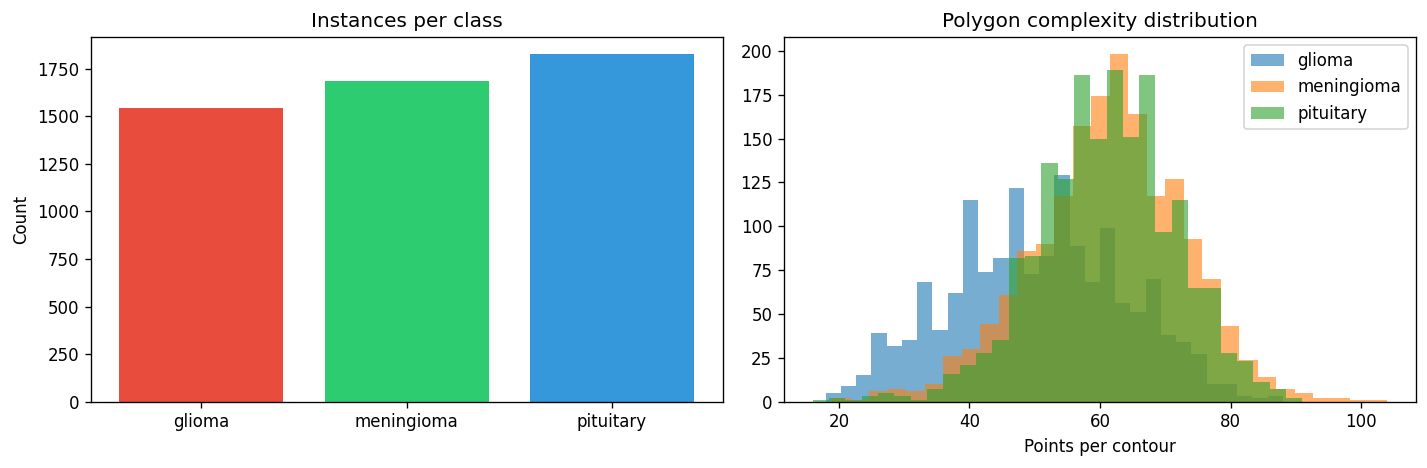

In [8]:
class_counter = Counter()
polygon_sizes = defaultdict(list)

for split in ["train", "val", "test"]:
    lbl_dir = YOLO_DATASET / "labels" / split
    if not lbl_dir.exists():
        continue
    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                cls_id = int(parts[0])
                class_counter[cls_id] += 1
                polygon_sizes[cls_id].append((len(parts) - 1) // 2)

print("Instance counts per class:")
for cid in sorted(class_counter):
    print(f"  {CLASS_NAMES[cid]}: {class_counter[cid]} instances, "
          f"avg {np.mean(polygon_sizes[cid]):.1f} polygon points")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

names = [CLASS_NAMES[i] for i in sorted(class_counter)]
counts = [class_counter[i] for i in sorted(class_counter)]
ax1.bar(names, counts, color=["#e74c3c", "#2ecc71", "#3498db"])
ax1.set_title("Instances per class")
ax1.set_ylabel("Count")

for cid in sorted(polygon_sizes):
    ax2.hist(polygon_sizes[cid], bins=30, alpha=0.6, label=CLASS_NAMES[cid])
ax2.set_title("Polygon complexity distribution")
ax2.set_xlabel("Points per contour")
ax2.legend()

plt.tight_layout()
plt.savefig(WORK_DIR / "class_distribution.png", dpi=150)
plt.show()

## 7. Training configuration

**Optimizer:** YOLO26 uses MuSGD, a hybrid of SGD and Muon inspired by Moonshot AI's Kimi K2
LLM training recipe. It is designed to give more stable convergence on limited data, which
is relevant here since training uses roughly 3,300 images after the validation split.

| Parameter | Value | Rationale |
|---|---|---|
| `imgsz` | 640 | Standard YOLO input resolution; balances detail vs. memory |
| `epochs` | 50 | Sufficient for convergence on ~3.3K images |
| `batch` | 16 | Fits a 16 GB P100 for the nano model |
| `patience` | 15 | Early stopping to prevent overfitting |
| `amp` | True | Mixed precision for memory efficiency |
| `box` / `cls` | 7.5 / 0.2 | Upweight localization loss relative to classification, since class imbalance is mild but boundary precision matters most |
| `overlap_mask` | True | Handles overlapping instance masks correctly |
| `mask_ratio` | 2 | Finer mask resolution during training |
| augmentation | conservative HSV + flips, mosaic 0.5 | Anatomically plausible augmentation; no rotation/shear that would distort tumor morphology |
| `seed` | 42 | Reproducibility |

In [9]:
TRAIN_PARAMS = dict(
    data=str(data_yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    amp=True,
    seed=42,
    task="segment",
    device=0,
    workers=4,
    verbose=True,
    plots=True,
    save=True,
    exist_ok=True,
    overlap_mask=True,   # handle overlapping masks correctly
    mask_ratio=2,        # finer mask resolution
    box=7.5,              # upweight box/localization loss
    cls=0.2,              # downweight classification loss
    cls_pw=0.9,            # classification positive weight
    # conservative imaging augmentation
    hsv_h=0.01,
    hsv_s=0.3,
    hsv_v=0.3,
    flipud=0.5,
    fliplr=0.5,
    mosaic=0.5,
)

In [10]:
print("Training YOLO26n-seg")

model = YOLO("yolo26n-seg.pt")
results = model.train(
    name="yolo26n_seg_brisc",
    project=str(WORK_DIR / "runs"),
    **TRAIN_PARAMS,
)

print("Training complete.")

Training YOLO26n-seg
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.7.1+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.2, cls_pw=0.9, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/brisc_yolo_seg/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.3, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=2, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=yolo26n

### Persist weights

Copies the best checkpoint to a stable location so it survives session restarts, and
confirms both the weights and the converted dataset are intact.

In [11]:
SAVE_DIR = WORK_DIR / "saved_weights"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

best_weights = WORK_DIR / "runs" / "yolo26n_seg_brisc" / "weights" / "best.pt"
shutil.copy2(best_weights, SAVE_DIR / "yolo26n_seg_best.pt")

print(f"Weights exist: {best_weights.exists()}")
print(f"Dataset exists: {YOLO_DATASET.exists()}")
for split in ["train", "val", "test"]:
    p = YOLO_DATASET / "images" / split
    if p.exists():
        print(f"  {split}: {len(os.listdir(p))} images")

Weights exist: True
Dataset exists: True
  train: 3342 images
  val: 589 images
  test: 860 images


## 8. Evaluation

The model is evaluated on the fully held-out test set (860 images) using COCO-style
metrics for both the box and mask heads: mAP at IoU 0.50 and averaged over IoU 0.50–0.95,
plus precision and recall.

In [12]:
def evaluate_model(model_path, data_yaml, split="test", name="model"):
    model = YOLO(model_path)
    metrics = model.val(
        data=str(data_yaml),
        split=split,
        imgsz=640,
        batch=16,
        task="segment",
        plots=True,
        save_json=True,
        verbose=True,
    )
    return {
        "Model": name,
        "Box mAP50": f"{metrics.box.map50:.4f}",
        "Box mAP50-95": f"{metrics.box.map:.4f}",
        "Mask mAP50": f"{metrics.seg.map50:.4f}",
        "Mask mAP50-95": f"{metrics.seg.map:.4f}",
        "Box Precision": f"{metrics.box.mp:.4f}",
        "Box Recall": f"{metrics.box.mr:.4f}",
    }, metrics


print("Evaluating YOLO26n-seg on the test set")
test_results, test_metrics = evaluate_model(best_weights, data_yaml_path, name="YOLO26n-seg")

df_results = pd.DataFrame([test_results])
print("\nTest-set results:")
print(df_results.to_string(index=False))

Evaluating YOLO26n-seg on the test set
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.7.1+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,469 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 923.9±439.9 MB/s, size: 29.1 KB)
val: Scanning /kaggle/working/brisc_yolo_seg/labels/test... 860 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 860/860 1.2Kit/s 0.7s0.0ss
val: New cache created: /kaggle/working/brisc_yolo_seg/labels/test.cache
requirements: Ultralytics requirement ['faster-coco-eval>=1.6.7'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 286ms
Prepared 1 package in 57ms
Installed 1 package in 6ms
 + faster-coco-eval==1.7.2

requirements: AutoUpdate success ✅ 1.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P

## 9. Training diagnostics

Standard Ultralytics diagnostic plots: loss/metric curves, confusion matrices, and
precision-recall curves for the trained run.

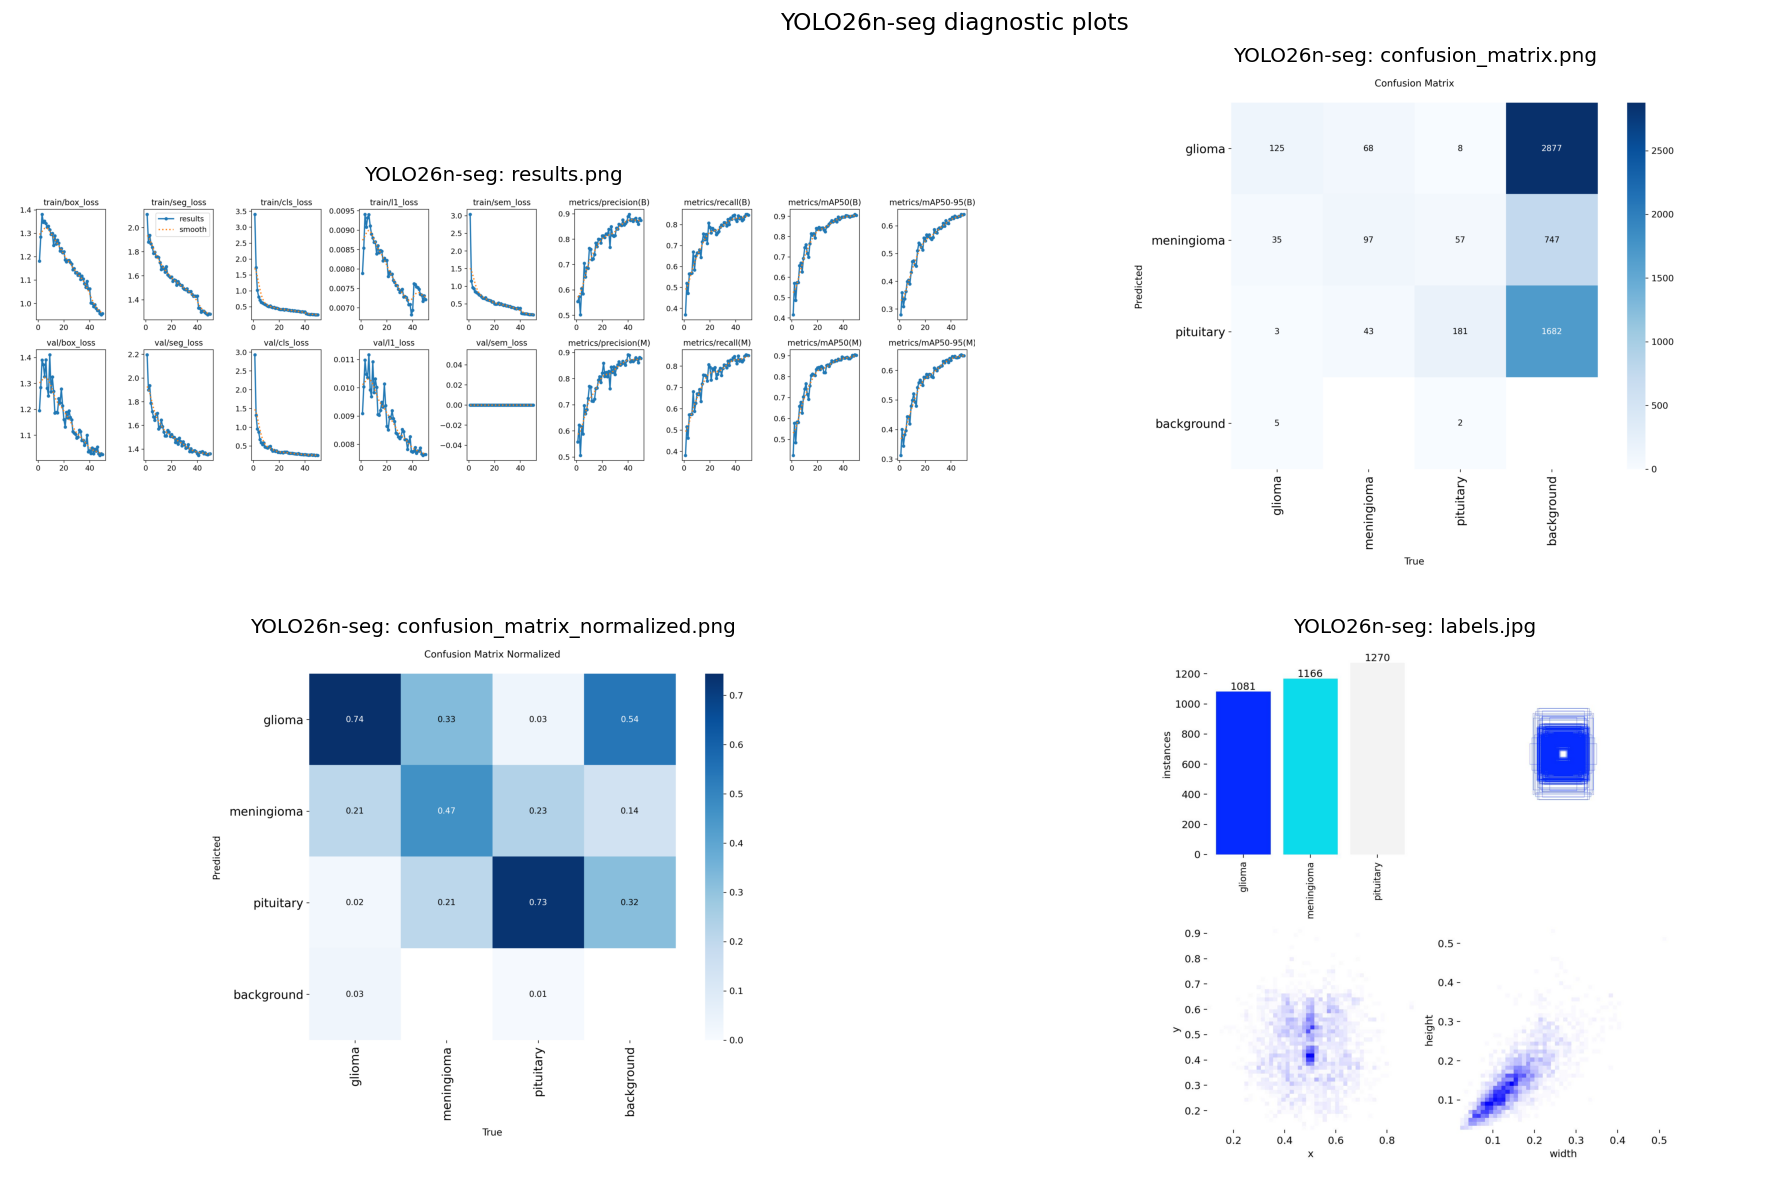

In [13]:
def show_plots(run_dir, model_name):
    plot_files = [
        "results.png", "confusion_matrix.png", "confusion_matrix_normalized.png",
        "PR_curve.png", "P_curve.png", "R_curve.png", "F1_curve.png",
        "labels.jpg", "labels_correlogram.jpg",
    ]
    found = [(p, run_dir / p) for p in plot_files if (run_dir / p).exists()]
    if not found:
        print(f"No plots found in {run_dir}")
        return

    cols = 2
    rows = (len(found) + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = axes.flatten()

    for i, (name, path) in enumerate(found):
        img = cv2.imread(str(path))
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"{model_name}: {name}")
        axes[i].axis("off")
    for i in range(len(found), len(axes)):
        axes[i].axis("off")

    plt.suptitle(f"{model_name} diagnostic plots", fontsize=14)
    plt.tight_layout()
    plt.show()


run_dir = WORK_DIR / "runs" / "yolo26n_seg_brisc"
show_plots(run_dir, "YOLO26n-seg")

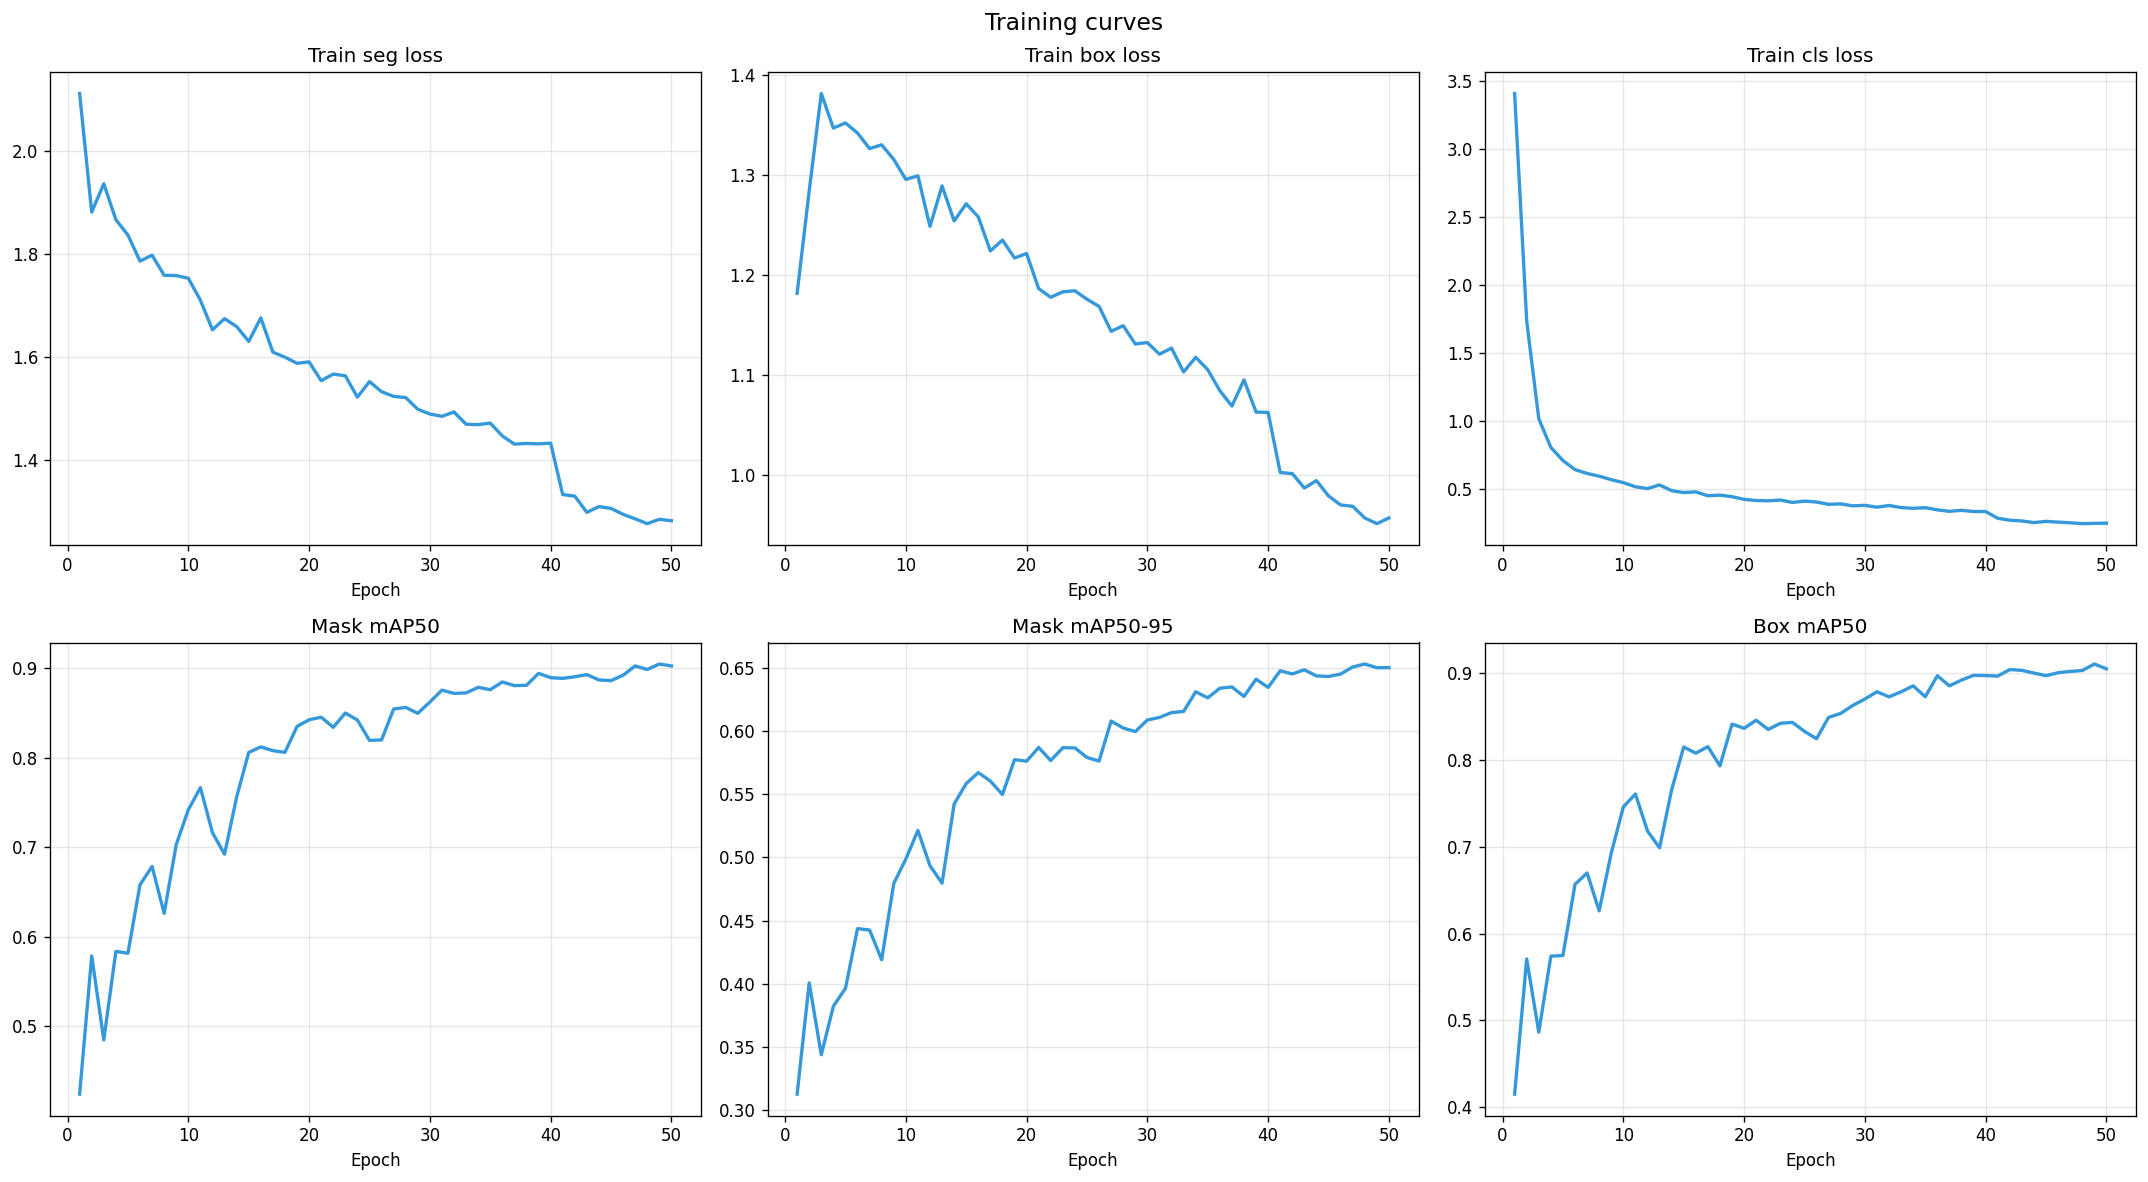

In [14]:
def load_results_csv(run_dir):
    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        return None
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    return df


df_history = load_results_csv(run_dir)

if df_history is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Column names vary slightly between Ultralytics versions.
    metric_cols = [
        ("train/seg_loss", "Train seg loss"),
        ("train/box_loss", "Train box loss"),
        ("train/cls_loss", "Train cls loss"),
        ("metrics/mAP50(M)", "Mask mAP50"),
        ("metrics/mAP50-95(M)", "Mask mAP50-95"),
        ("metrics/mAP50(B)", "Box mAP50"),
    ]

    for ax, (col, title) in zip(axes.flatten(), metric_cols):
        if col in df_history.columns:
            ax.plot(df_history["epoch"], df_history[col], color="#3498db", linewidth=2)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.3)

    plt.suptitle("Training curves", fontsize=14)
    plt.tight_layout()
    plt.savefig(WORK_DIR / "training_curves.png", dpi=150)
    plt.show()
else:
    print("Could not load results.csv for this run.")

## 10. Qualitative predictions

Segmentation overlays on unseen test images, with per-image detection counts and mean
confidence.

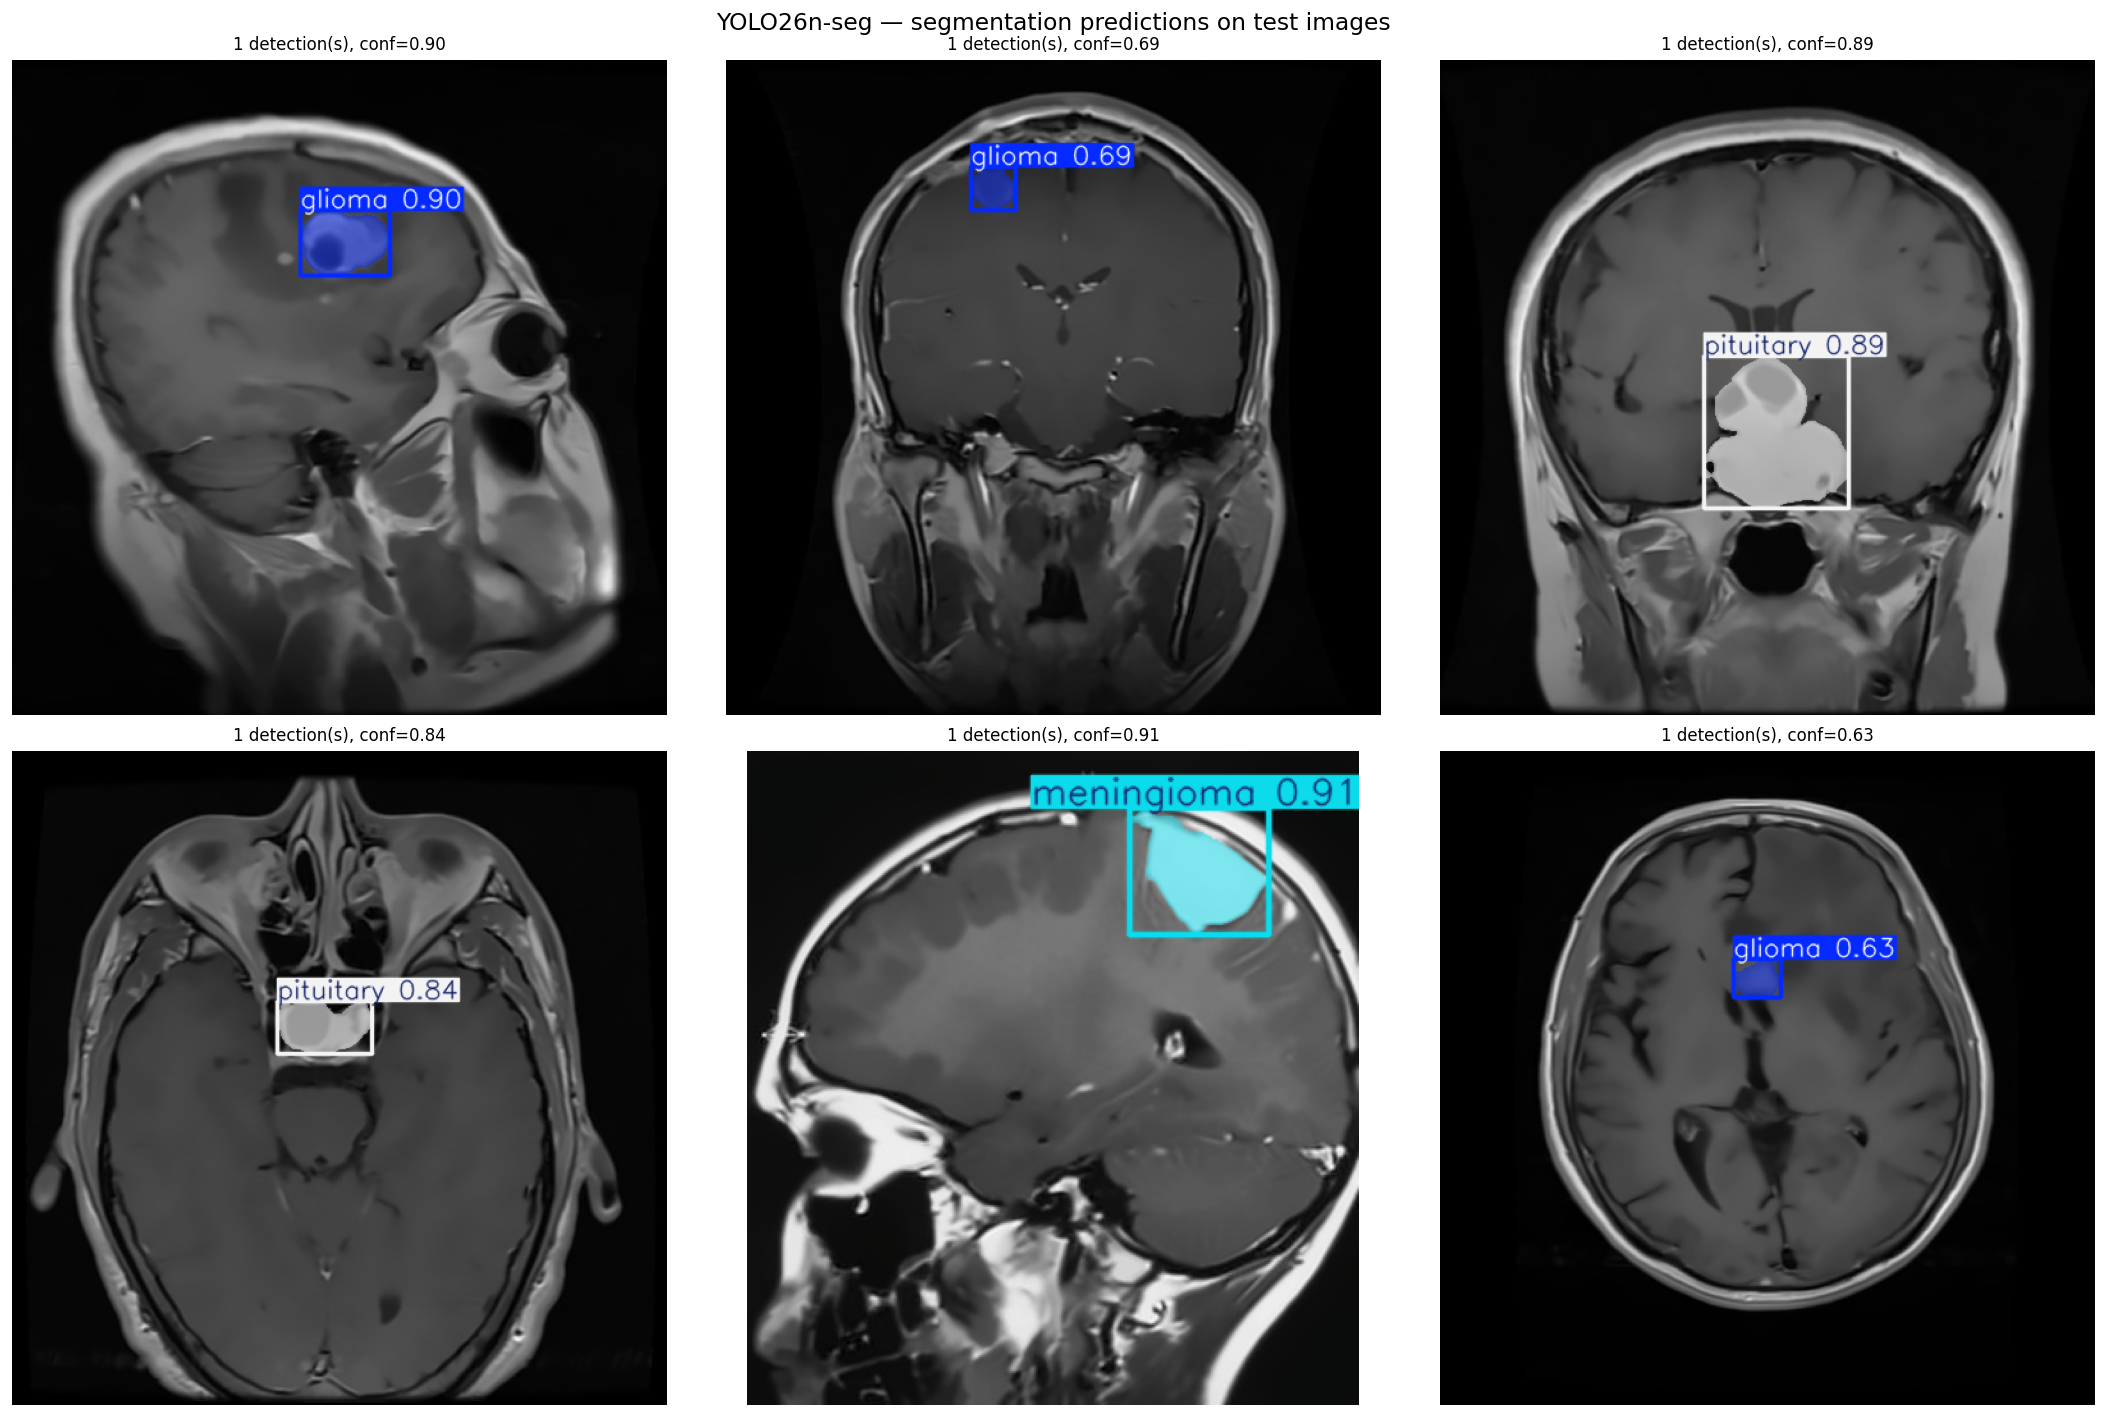

In [15]:
def predict_and_show(model_path, model_name, images, n=6):
    model = YOLO(model_path)
    results = model.predict(
        source=[str(img) for img in images[:n]],
        imgsz=640, conf=0.25, save=False, verbose=False,
    )

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, (r, img_path) in enumerate(zip(results, images[:n])):
        plotted_rgb = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)

        n_det = len(r.boxes) if r.boxes is not None else 0
        conf_str = ""
        if r.boxes is not None and len(r.boxes) > 0:
            conf_str = f", conf={r.boxes.conf.cpu().numpy().mean():.2f}"

        axes[i].imshow(plotted_rgb)
        axes[i].set_title(f"{n_det} detection(s){conf_str}", fontsize=10)
        axes[i].axis("off")

    plt.suptitle(f"{model_name} — segmentation predictions on test images", fontsize=14)
    plt.tight_layout()
    plt.savefig(WORK_DIR / "test_predictions.png", dpi=150)
    plt.show()


test_images = sorted((YOLO_DATASET / "images" / "test").glob("*.jpg"))
if len(test_images) < 6:
    test_images += sorted((YOLO_DATASET / "images" / "val").glob("*.jpg"))
random.shuffle(test_images)

predict_and_show(best_weights, "YOLO26n-seg", test_images)

## 11. Results & discussion

**Test-set performance (860 held-out images, 914 instances; final training run, 50/50
epochs completed in 1.95 hours with no early stop):**

| Class | Images | Instances | Box P | Box R | Box mAP50 | Box mAP50-95 | Mask P | Mask R | Mask mAP50 | Mask mAP50-95 |
|---|---|---|---|---|---|---|---|---|---|---|
| All | 860 | 914 | 0.889 | 0.797 | 0.883 | 0.639 | 0.893 | 0.801 | 0.883 | 0.637 |
| Glioma | 254 | 295 | 0.813 | 0.636 | 0.756 | 0.515 | 0.809 | 0.631 | 0.749 | 0.480 |
| Meningioma | 306 | 311 | 0.952 | 0.923 | 0.972 | 0.780 | 0.952 | 0.923 | 0.972 | 0.800 |
| Pituitary | 300 | 308 | 0.901 | 0.831 | 0.922 | 0.621 | 0.919 | 0.847 | 0.929 | 0.631 |

**Observations:**
- The model separates the three tumor types well overall, reaching a mask mAP50 of 0.883
  and box mAP50 of 0.883 on held-out data it never saw during training.
- **Glioma is consistently the hardest class**, and specifically on *recall* (0.636 box /
  0.631 mask) rather than precision (0.813 box / 0.809 mask) — when the model flags a
  glioma it's usually right, but it misses substantially more glioma instances than it
  does meningioma or pituitary. This is consistent with glioma's typically infiltrative,
  poorly circumscribed margins compared to the well-defined boundaries of meningioma and
  pituitary adenomas: low-contrast or diffuse tumor extent is more likely to fall under
  the detection threshold entirely, rather than being detected but mis-classified.
- Meningioma is the easiest class by a clear margin (mask mAP50 0.972, mAP50-95 0.800),
  consistent with its characteristically sharp, well-circumscribed borders on T1-weighted
  imaging — the same property that makes it comparatively easy for radiologists too.
- The gap between mAP50 and mAP50-95 is largest for glioma (0.749 → 0.480, a 0.269 drop)
  and smallest for meningioma (0.972 → 0.800, a 0.172 drop). Even where glioma is detected,
  the predicted mask boundary agrees less precisely with the ground truth — again pointing
  to boundary ambiguity rather than gross localization failure as the main error mode.

**Limitations:**
- Single 2D slice input; no volumetric (3D) context across adjacent slices is used, which
  can help disambiguate infiltrative tumor margins like glioma's.
- Only one architecture/size (YOLO26n-seg) was evaluated here; a larger backbone or a
  medical-imaging-specific architecture (e.g., nnU-Net) would be a natural comparison point.
- Polygon simplification (`epsilon = 0.002`) trades a small amount of boundary fidelity for
  training speed; worth quantifying its effect on Dice/mask mAP directly.

**Possible next steps:**
- Investigate glioma recall specifically (e.g. lowering the confidence threshold, or
  inspecting false negatives directly) given it's the dominant error source identified above.
- Compare against a U-Net/nnU-Net baseline for a segmentation-native architecture reference.
- Incorporate multi-slice (2.5D) context.
- Stratify errors by tumor size and plane (axial/coronal/sagittal) to see whether failure
  modes are anatomically consistent.

## References
Fateh, et al. (2026). BRISC: Annotated Dataset for Brain Tumor Segmentation and Classification, *nature*,*Scientific Data*.